In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import pickle
import sbi.utils as utils
import torch
import seaborn as sns
from seaborn import kdeplot
import numpy as np
import sys  
sys.path.insert(1, '../')
from collective_posterior import CollectivePosterior
from simulators import FWDPY, wrapper

from seaborn import histplot
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400

import warnings
warnings.simplefilter('ignore', Warning)


import matplotlib
def change_font(fontsize):
    matplotlib.rcParams['xtick.labelsize'] = fontsize
    matplotlib.rcParams['ytick.labelsize'] = fontsize
    matplotlib.rcParams['font.size'] = fontsize
    matplotlib.rcParams['axes.labelsize'] = fontsize
    matplotlib.rcParams['legend.fontsize'] = fontsize

Text(0, 0.5, 'Mean Trait Value')

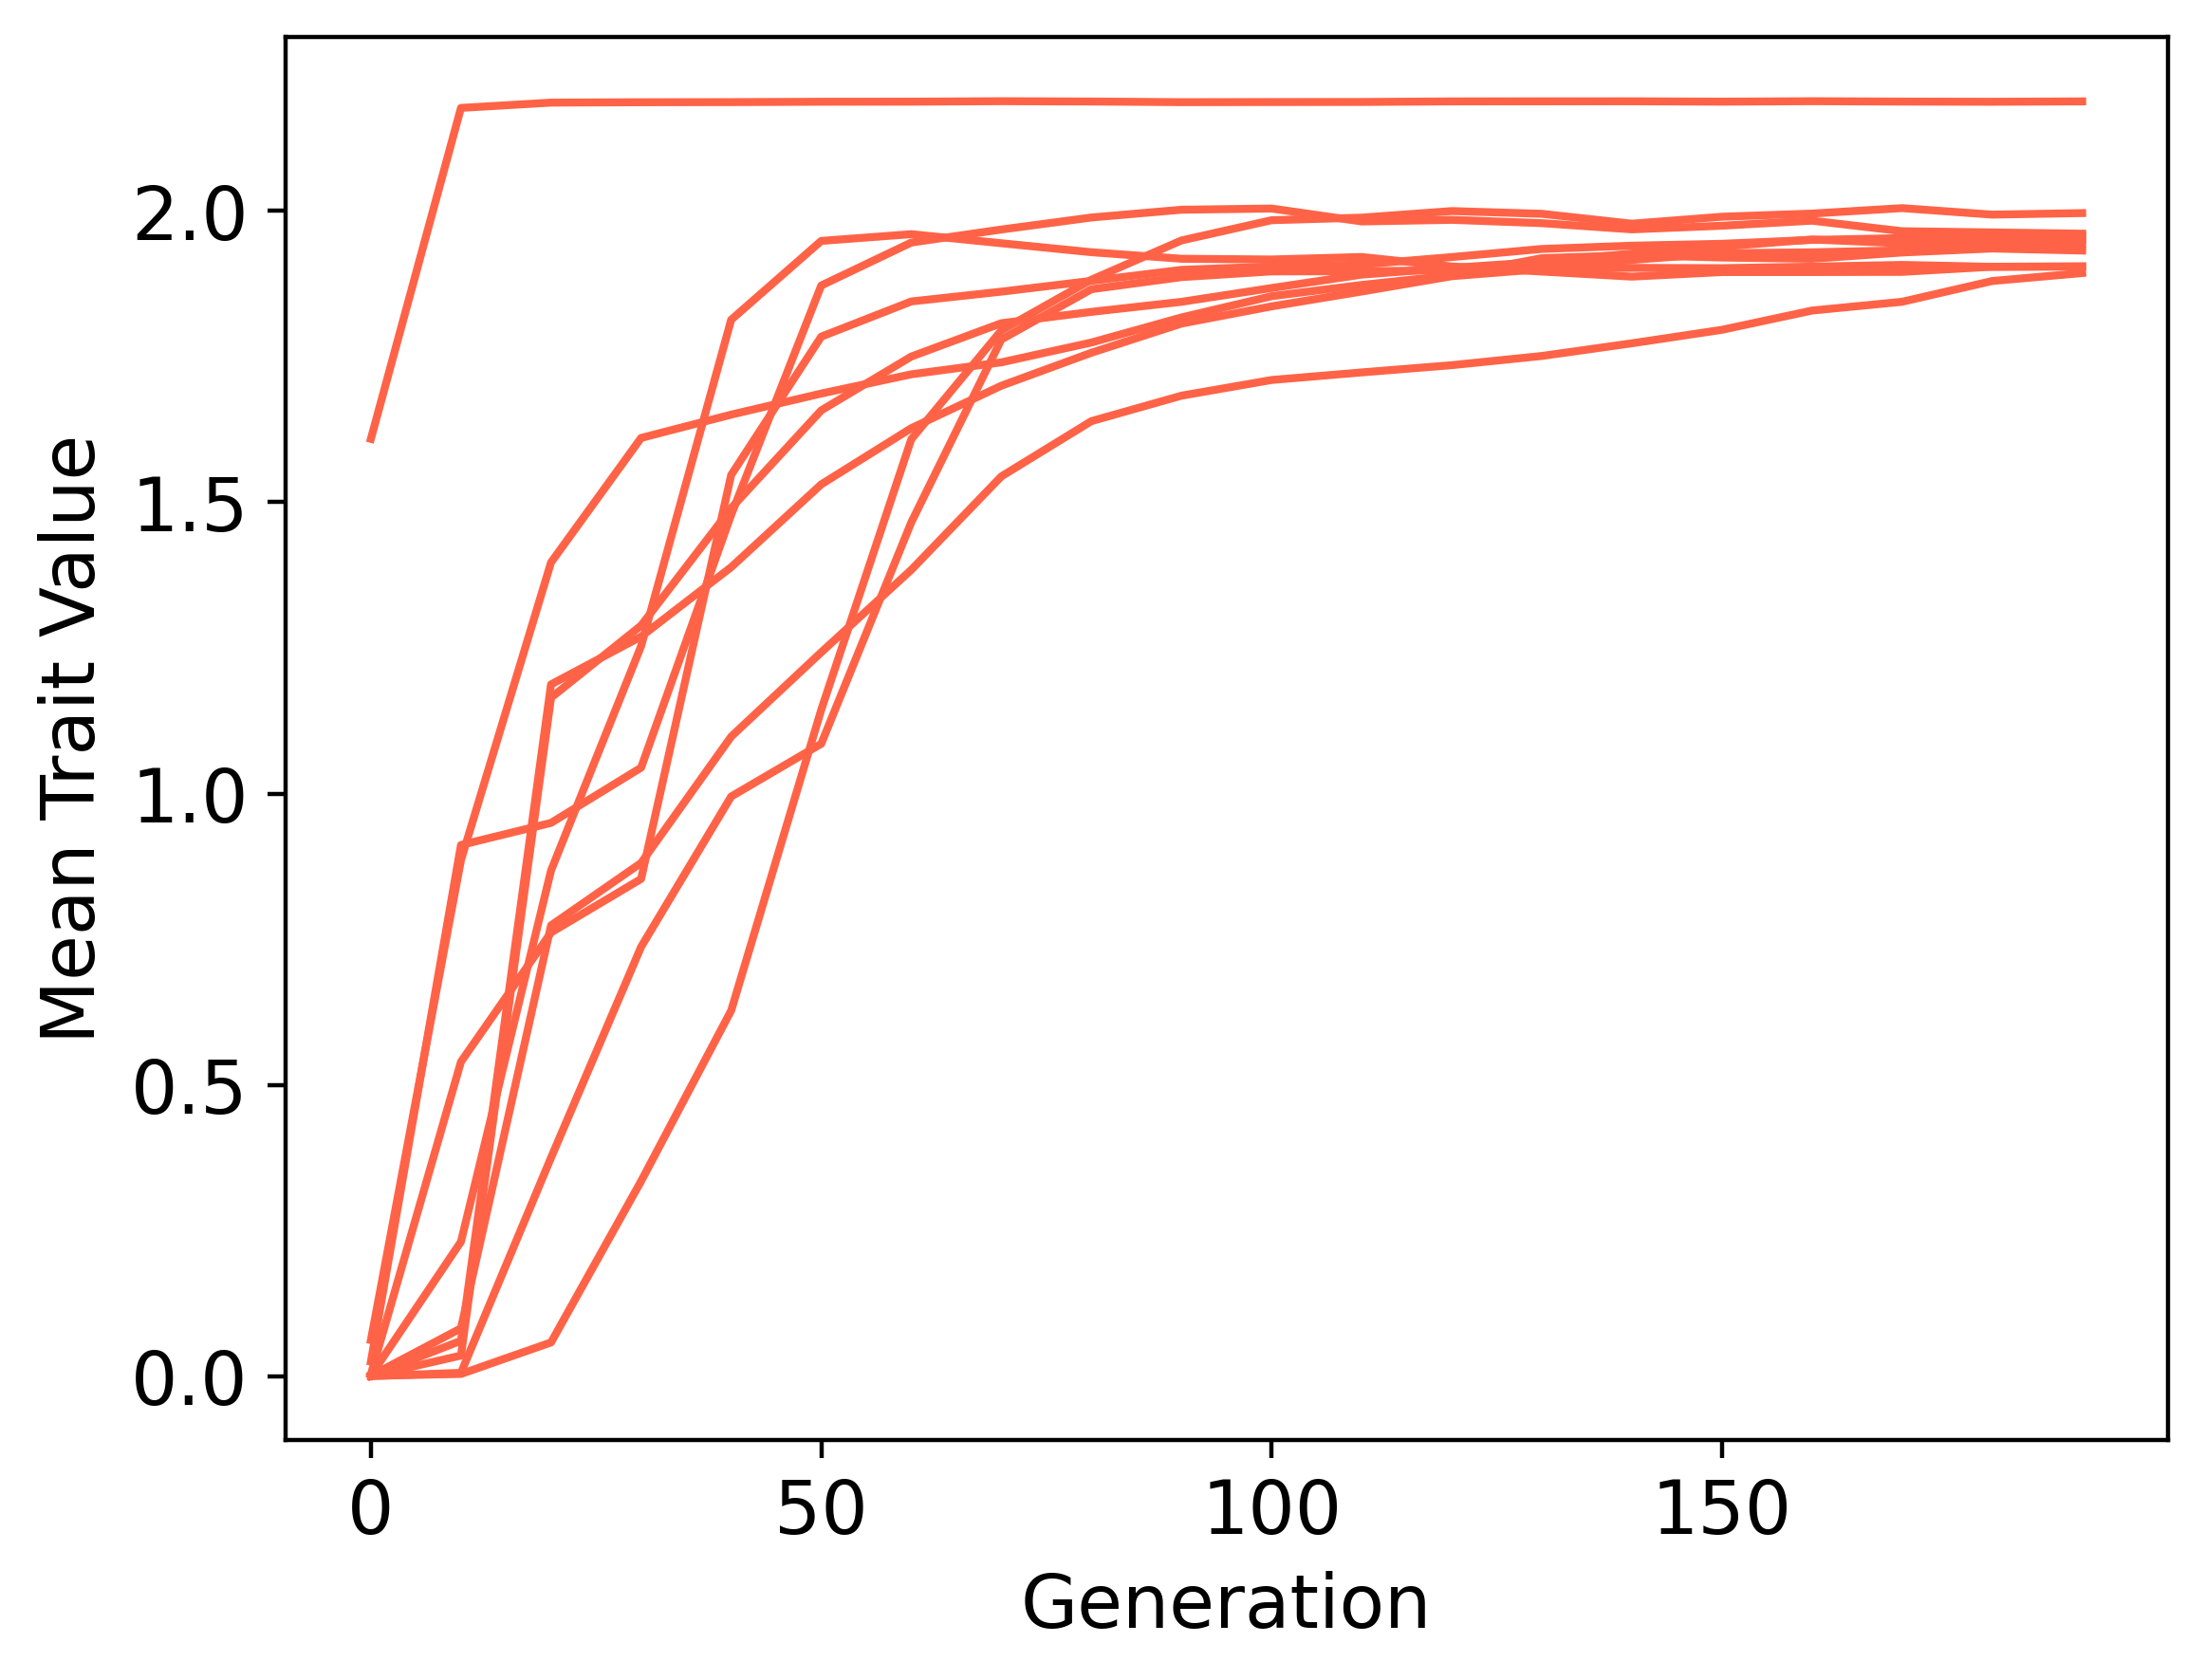

In [7]:
from inference_utils import get_prior

prior = get_prior('FWDPY')
th = prior.sample((1,)).squeeze() # Example parameters in log10 space
X = wrapper(FWDPY, parameters=th, reps=10) 
change_font(14)

for i in range(len(X)):
    plt.plot(10*np.arange(0,len(X[i])),X[i], color='tomato', label='regular' if i==0 else '')
plt.xlabel('Generation')
plt.ylabel('Mean Trait Value')

Text(0, 0.5, 'Mean Trait Value')

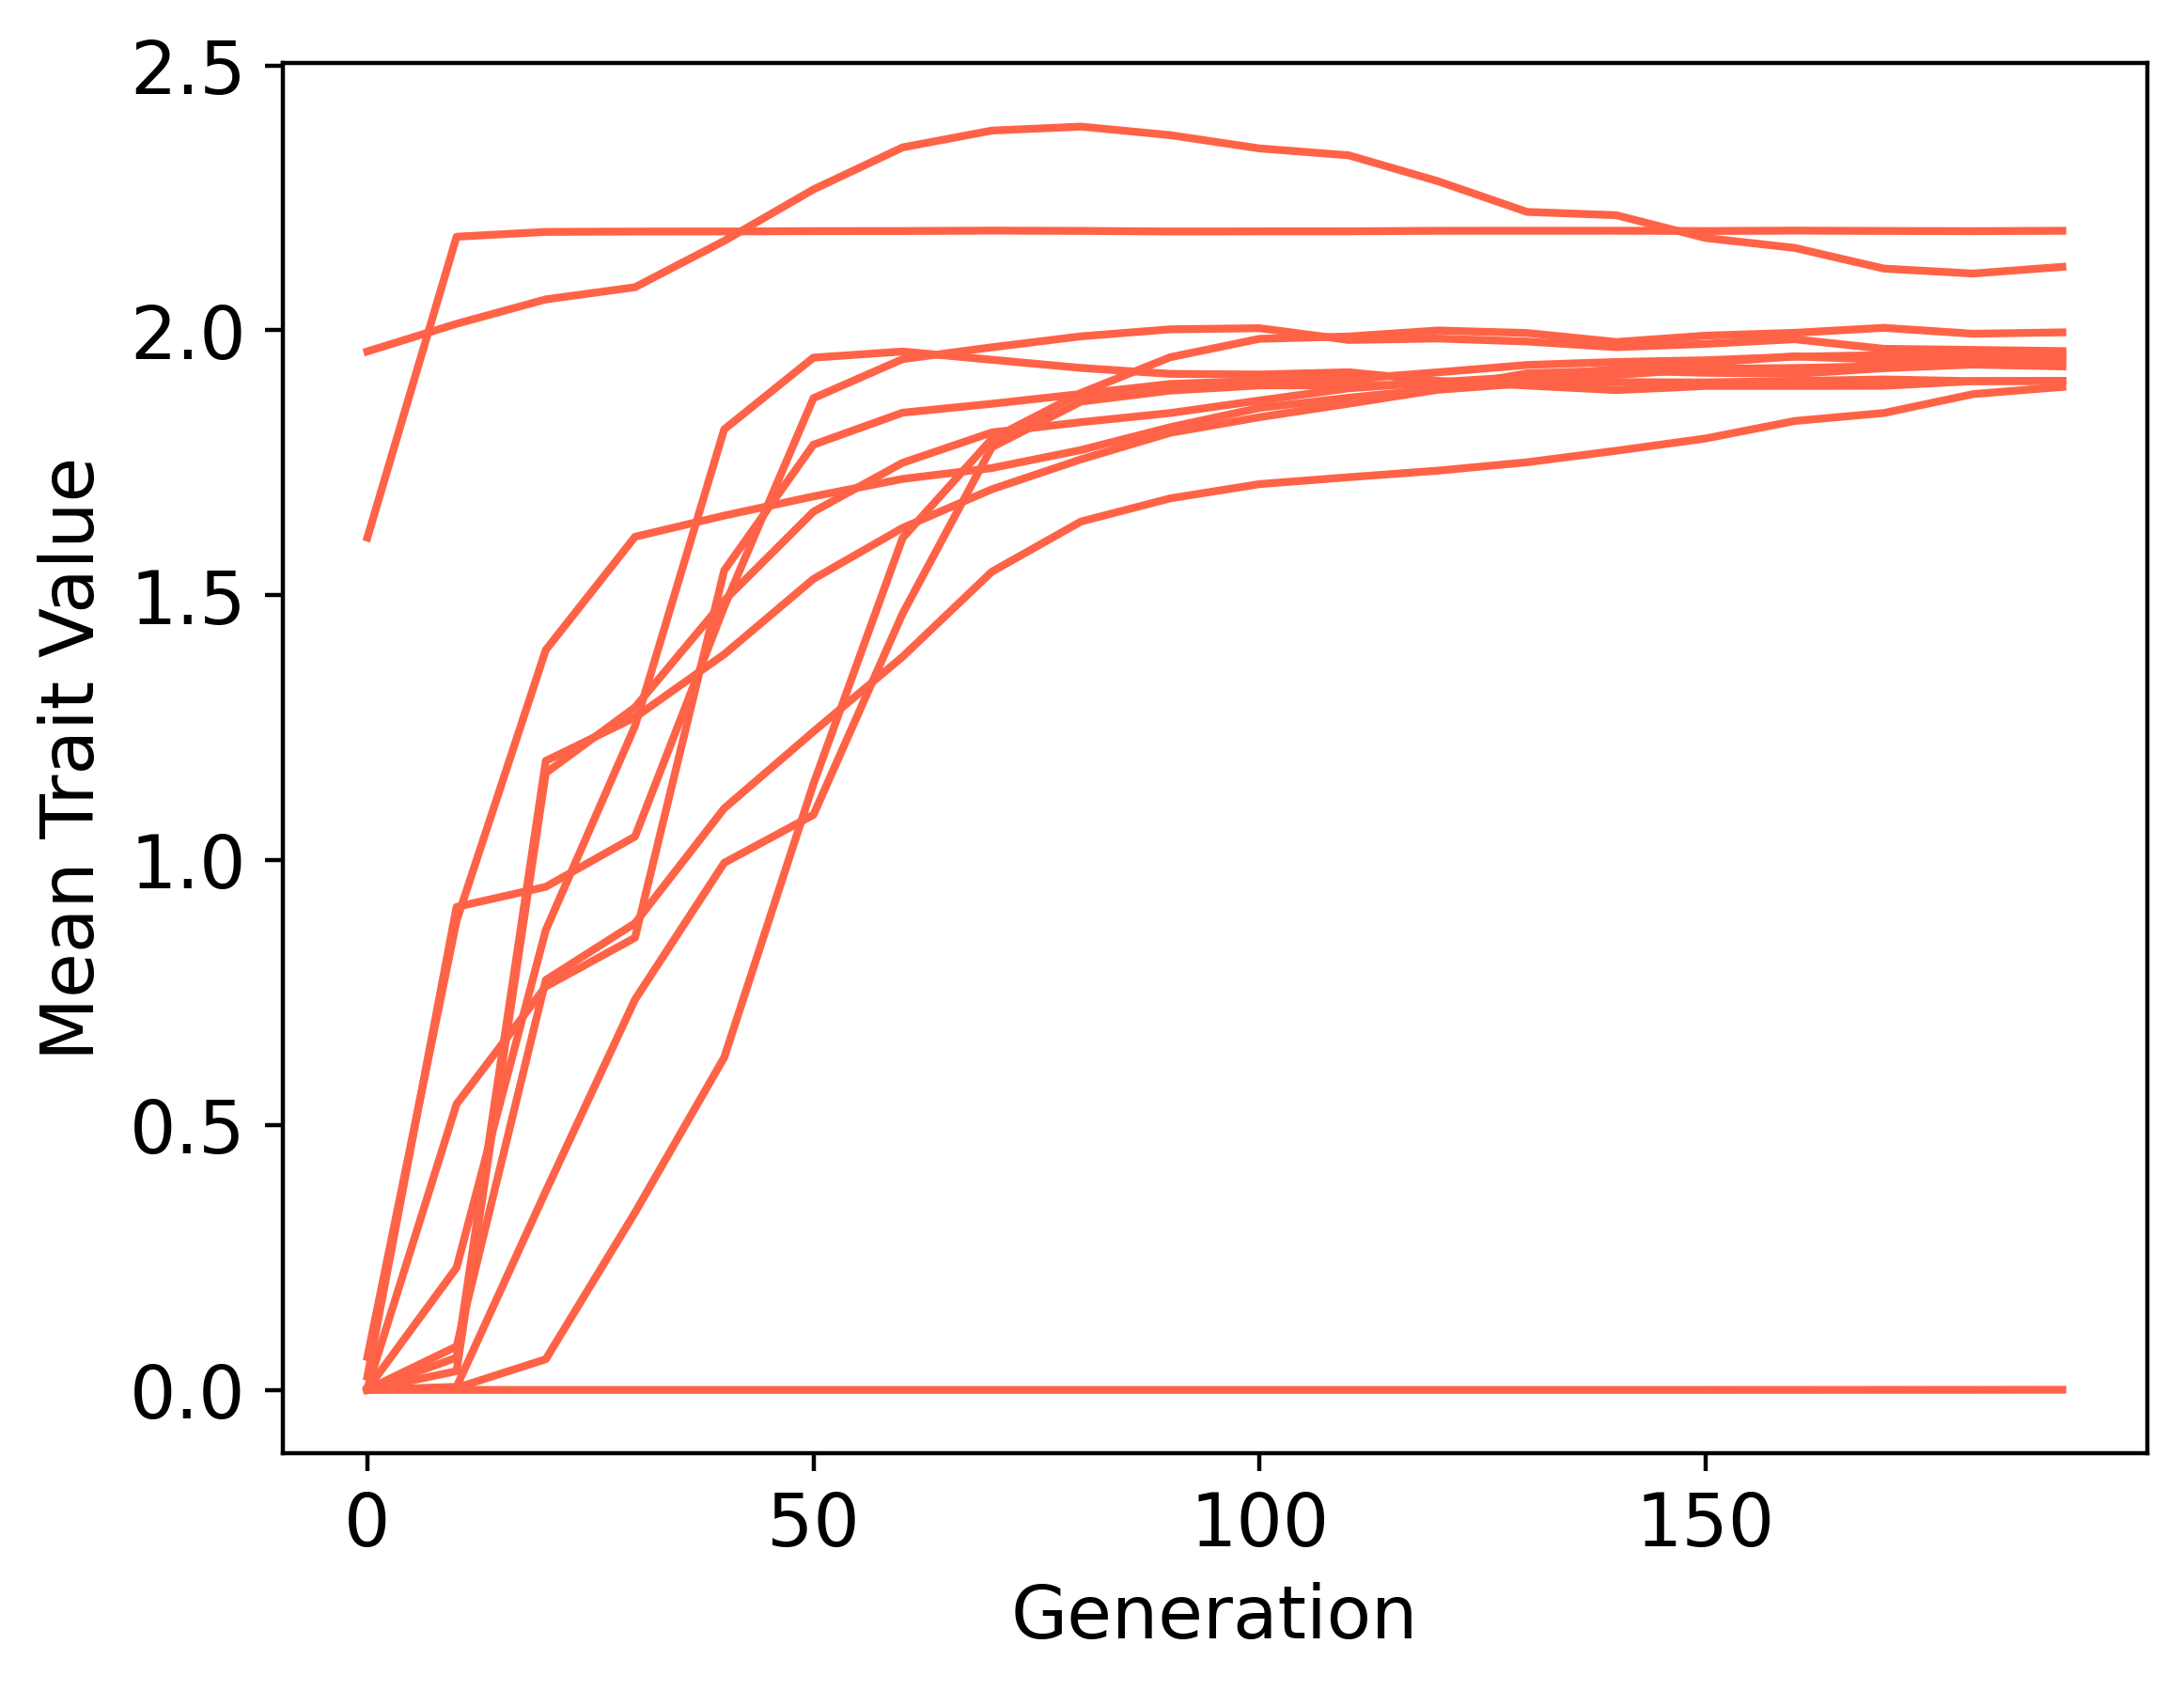

In [8]:
x_outlier = FWDPY(th+1.25).reshape(1,-1)
x_oo = FWDPY(th-1.25).reshape(1,-1)
X_o = np.concatenate([X,x_outlier, x_oo])
for i in range(len(X_o)):
    plt.plot(10*np.arange(0,len(X_o[i])),X_o[i], color='tomato')
plt.xlabel('Generation')
plt.ylabel('Mean Trait Value')

Rejection Sampling: 10000it [00:02, 3338.72it/s]           
Rejection Sampling: 281it [00:03, 81.90it/s]               
Rejection Sampling:  14%|█▍        | 29/200 [00:08<00:49,  3.44it/s]


KeyboardInterrupt: 

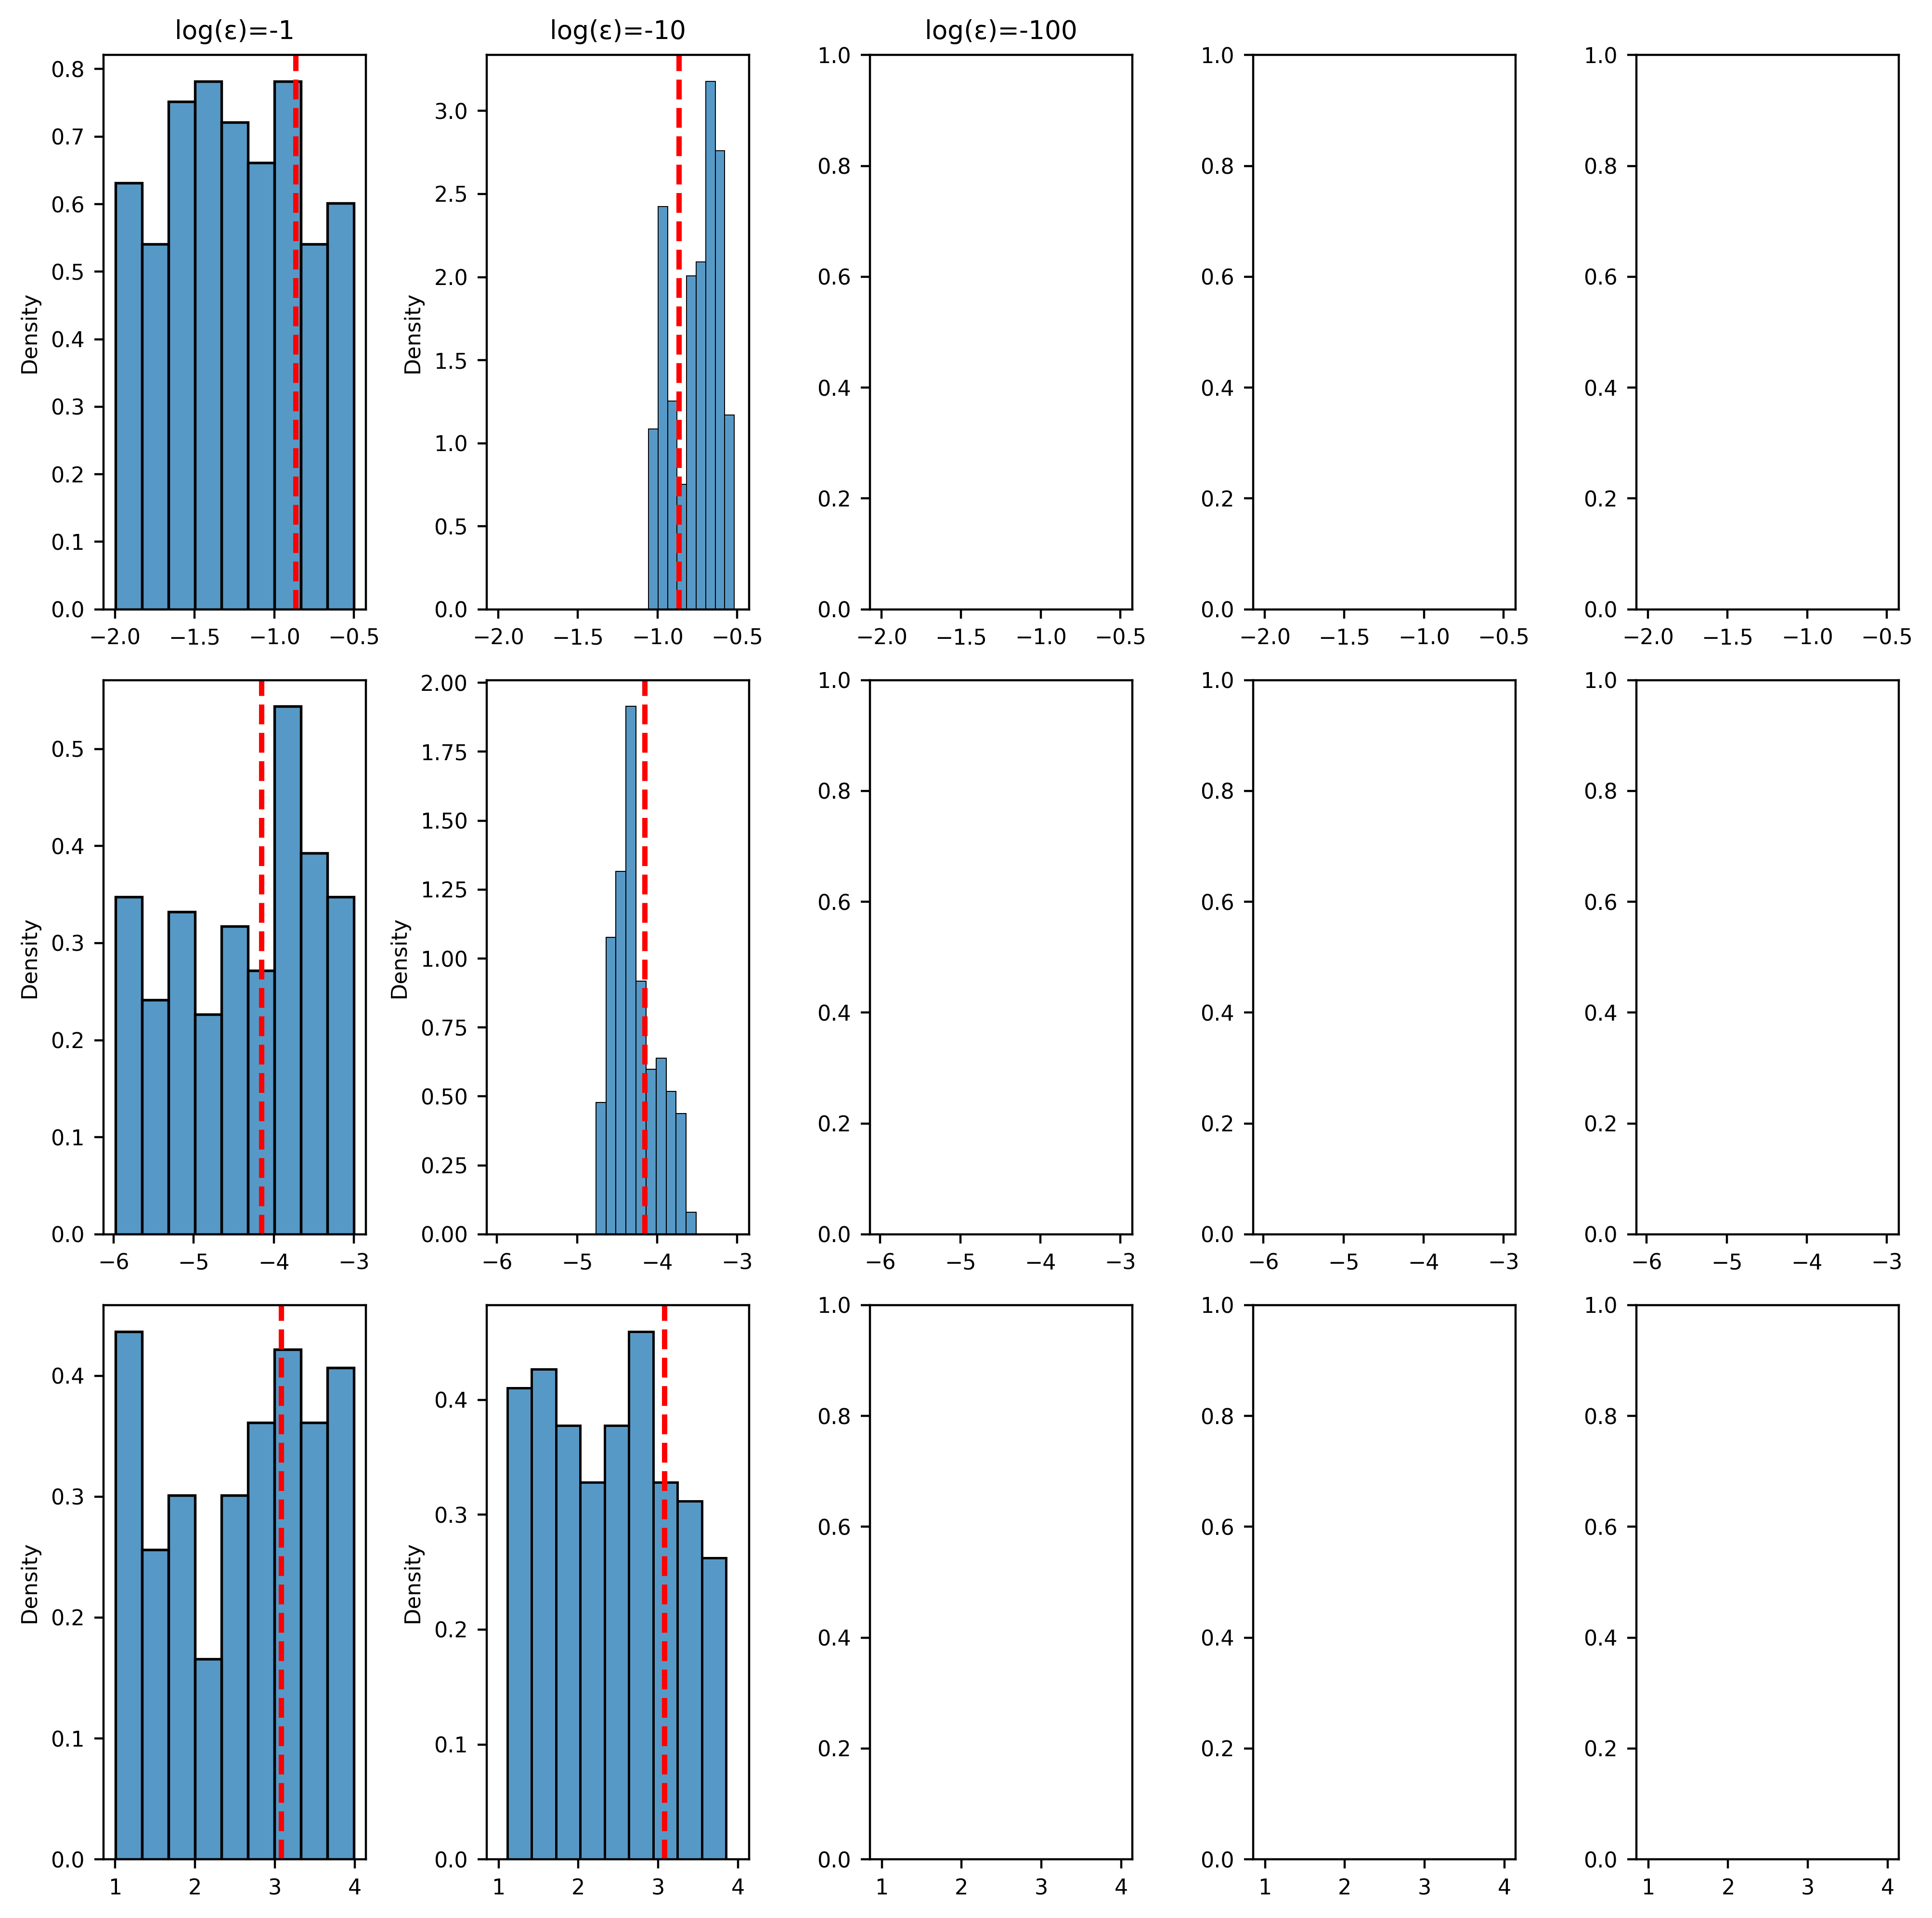

In [10]:

posterior = pickle.load(open('posterior_FWDPY_100000_20.pkl', 'rb'))

change_font(8)
fig, ax = plt.subplots(3,5, tight_layout=True, figsize=(10,10), sharex='row')
for i in range(5):
    epsilon = -10**i
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X_o, posterior, 1, epsilon)
    op.get_log_C()
    samps = op.rejection_sample(200)
    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density')
        ax[j,i].axvline(th[j], color='red', lw=2, ls='--')

Rejection Sampling: 10000it [00:00, 49923.75it/s]                               
Rejection Sampling: 10000it [00:00, 50686.39it/s]                               
Rejection Sampling: 224it [00:00, 1086.83it/s]                                  
Rejection Sampling: 211it [00:00, 1085.79it/s]                                  
Rejection Sampling: 177it [00:00, 982.89it/s]                                   
Rejection Sampling: 10000it [00:00, 48405.79it/s]                               
Rejection Sampling: 10000it [00:00, 42612.18it/s]                               
Rejection Sampling: 218it [00:00, 1012.07it/s]                                  
Rejection Sampling: 337it [00:00, 1437.01it/s]                                  
Rejection Sampling: 119it [00:01, 110.38it/s]                                   


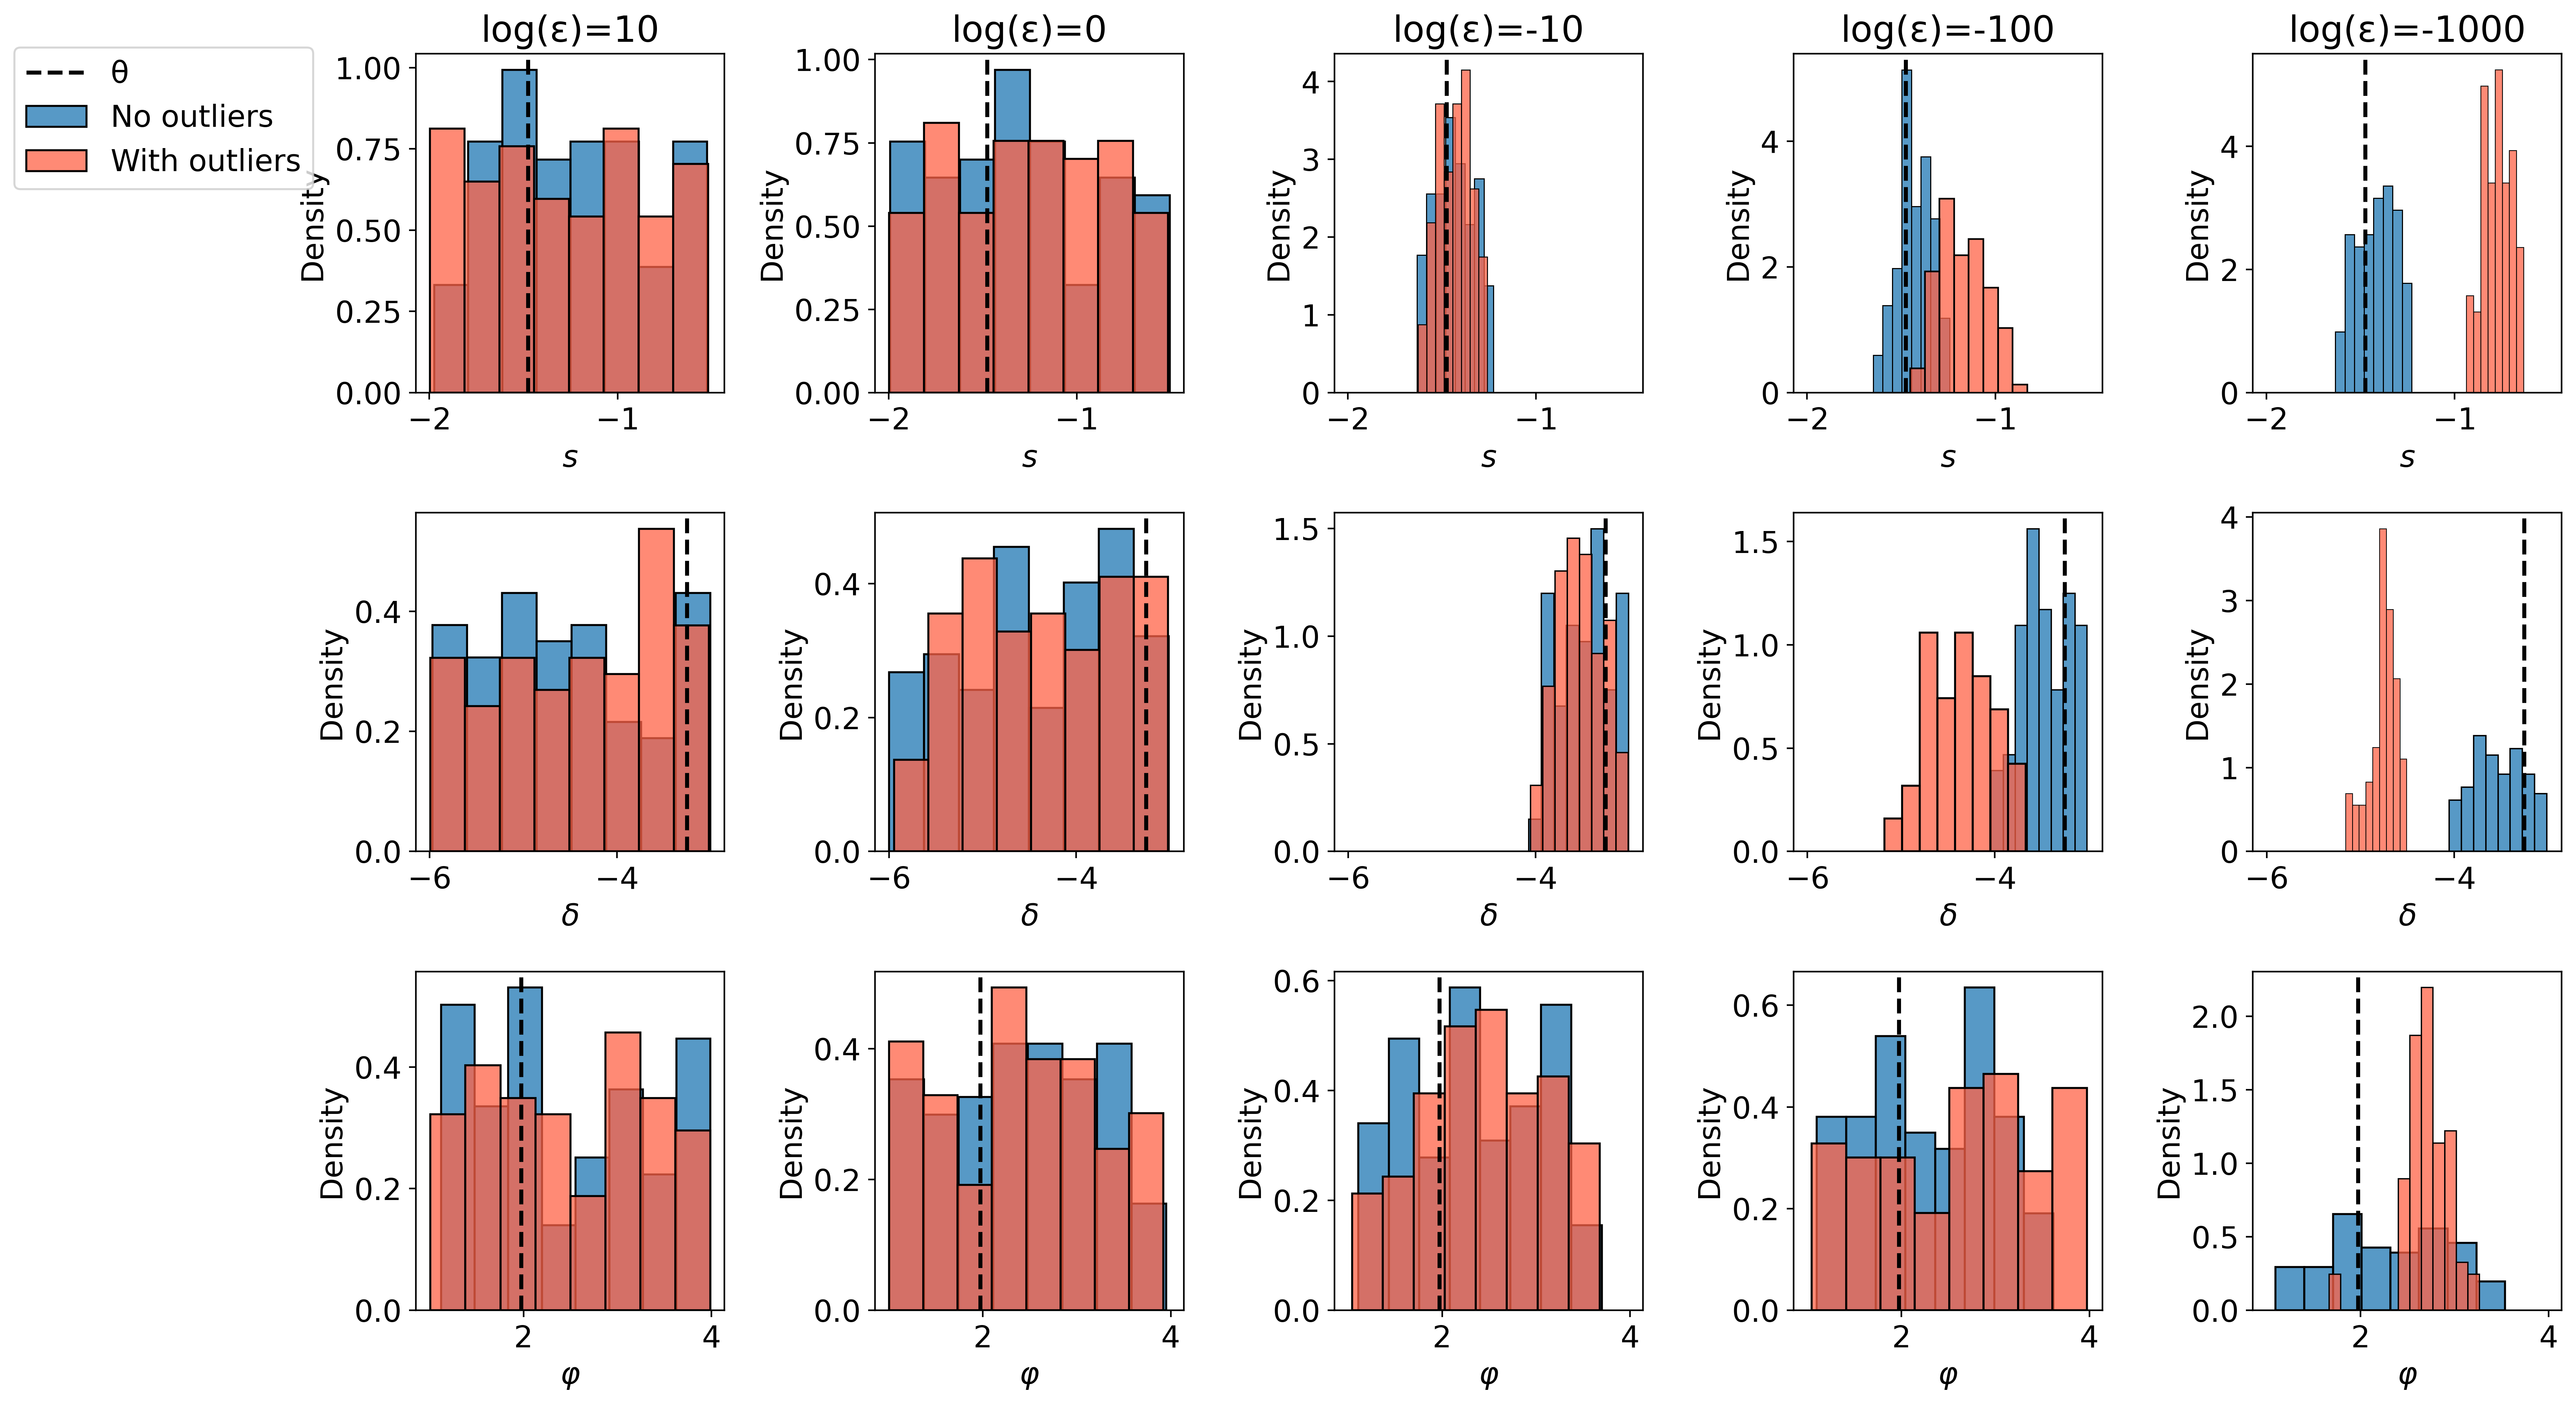

In [7]:
change_font(15)
fig, ax = plt.subplots(3,5, tight_layout=True, figsize=(18,10), sharex='row')
for l in range(5):
    ax[0,l].set_xlabel('$s$')
    ax[1,l].set_xlabel('$δ$')
    ax[2,l].set_xlabel('$φ$')
    
epsilons = [10,0,-10,-100,-1000]

for i in range(len(epsilons)):
    epsilon = epsilons[i]
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X, posterior, 1, epsilon)
    op.get_log_C()
    samps = op.rejection_sample(100)
    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density', label = 'No outliers' if i*j==0 else '')
        
for i in range(len(epsilons)):
    epsilon = epsilons[i]
    ax[0,i].set_title(f'log(ε)={int(epsilon)}')
    op = CollectivePosterior(prior, X_o, posterior, 1, epsilon)
    op.get_log_C()
    samps = op.rejection_sample(100)
    for j in range(len(samps[0])):
        histplot(samps[:,j], ax=ax[j,i], stat='density', color='tomato', label = 'With outliers' if i*j==0 else '')
        ax[j,i].axvline(th[j], color='k', lw=2, ls='--', label='θ' if i*j==0 else '')

ax[0,0].legend(loc=(-1.3,0.6))